This notebook is an example using only one minibox of what the script does for all the miniboxes we divided the simulation into

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [2]:
# ASTRID cosmology values
hubble, z = 0.6774, 2.5

# Calculating Px

As I will need to obtain the radial separation between two skewers, I cannot mask just yet. I need to do that afterwards. We will call a folder that contains all the deltas without any masking

In [3]:
data = '/pscratch/sd/l/lflores/astrid_hcd_outputs/FFTs/ffts_0.3_24/minibox_01.hdf5'
Nmbox = 25

with h5py.File(data, 'r') as f:
    print('Atributes:')
    for k in f.attrs.keys():
        print(f'{k} = {f.attrs[k]}')
    print('----------------') 
    # Atributes
    logNHi_min = f.attrs['logNHI_min']
    logNHi_max = f.attrs['logNHI_max']
    smth_factor = f.attrs['Smoothing factor']
    Lbox = f.attrs['box_size_Mpch']
    Lmbox = f.attrs['minibox_size_Mpch']
    Nsk = f.attrs['skewers_per_side']
    Np = f.attrs['pixels_per_skewer']
    Pw = f.attrs['pixel_width_Mpch']
    Ssk = f.attrs['skewer_separation_Mpch']
    print('Data:')
    print(f.keys())
    # Data
    fft_tot = f['fft_tot'][:]
    print('fft_tot shape:', fft_tot.shape)
    fft_lya = f['fft_lya'][:]
    print('fft_lya shape:', fft_lya.shape)
    fft_hcd = f['fft_hcd'][:]
    print('fft_hcd shape:', fft_hcd.shape)
    fft_lyahcd = f['fft_lyahcd'][:]
    print('fft_lyahcd shape:', fft_lyahcd.shape)
    k_los = f['k_los'][:]
    print('k_los shape', k_los.shape)
    C = f['C'][()]
    print('C = ', C)
    colden = f['colden'][:]
    print('colden shape', colden.shape)


Atributes:
Smoothing factor = 0.3
box_size_Mpch = 250
logNHI_max = 24.0
logNHI_min = 0
minibox_size_Mpch = 50.0
pixel_width_Mpch = 0.1
pixels_per_skewer = 2500
skewer_separation_Mpch = 0.5
skewers_per_side = 100
----------------
Data:
<KeysViewHDF5 ['C', 'colden', 'fft_hcd', 'fft_lya', 'fft_lyahcd', 'fft_tot', 'k_los']>
fft_tot shape: (10000, 1251)
fft_lya shape: (10000, 1251)
fft_hcd shape: (10000, 1251)
fft_lyahcd shape: (10000, 1251)
k_los shape (1251,)
C =  0.005908550712377059
colden shape (10000, 2500)


## Radial distance

In [4]:
ix, iy = np.divmod(np.arange(Nsk), Lmbox)  # This gives me the coordinates of each skewer within the minibox
dx = ix[:, None] - ix[None, :]
dy = iy[:, None] - iy[None, :]
dr = np.sqrt(dx**2 + dy**2)*Ssk  # This matrix contains the radial distance (Mpc/h) between all skewers within the minibox

In [23]:
r_bins = np.linspace(dr.min(), dr.max(), 6)  # 5 radial bins Mpc/h
print(len(r_bins), 'radial edges (Mpc/h) defined to have', len(r_bins)-1, 'radial bins:', r_bins, '[Mpc/h]')

6 radial edges (Mpc/h) defined to have 5 radial bins: [ 0.          4.9010203   9.8020406  14.70306091 19.60408121 24.50510151] [Mpc/h]


## Masking skewers

In [18]:
from Calculate_deltas import mask_skewers

logNHi_min, logNHi_max = 0, 21.3
_, _, (fft_tot_mask, fft_lya_mask, fft_hcd_mask, fft_lyahcd_mask, dr_flatten_mask) = mask_skewers(colden, logNHi_min, logNHi_max, Nsk, fft_tot, fft_lya, fft_hcd, fft_lyahcd, dr.flatten())

## Computing Px

### Total

In [15]:
px_tot = []
for i, r_value in enumerate(r_bins[:-1]):
    r_mask = (dr_flatten_mask > r_value) & (dr_flatten_mask < r_bins[i+1])
    fft_tot_2mask = fft_tot_mask[r_mask]
    
    pxs_tot = fft_tot_2mask*fft_tot_2mask.conjugate()*Lbox/(Np**2)
    px_tot.append(np.mean(pxs_tot, axis=0))
px_tot = np.array(px_tot)

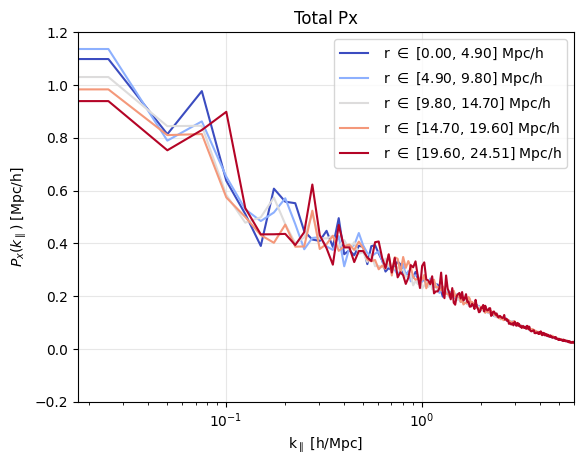

In [59]:
colors = plt.cm.coolwarm(np.linspace(0,1,len(r_bins)-1))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(px_tot)):
    plt.plot(k_los, px_tot[i], label=f' r $\\in$ [%.2f, %.2f] Mpc/h' %(r_bins[i], r_bins[i+1]))
plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.ylim(-0.2, 1.2)
plt.xlabel(r'k$_\parallel$ [h/Mpc]')
plt.ylabel(r'$P_x(k_\parallel)$ [Mpc/h]')
plt.title('Total Px');

## Lya

In [31]:
px_lya = []
for i, r_value in enumerate(r_bins[:-1]):
    r_mask = (dr_flatten_mask > r_value) & (dr_flatten_mask < r_bins[i+1])
    fft_lya_2mask = fft_lya_mask[r_mask]
    
    pxs_lya = fft_lya_2mask*fft_lya_2mask.conjugate()*Lbox/(Np**2)
    px_lya.append(np.mean(pxs_lya, axis=0))
px_lya = np.array(px_lya)

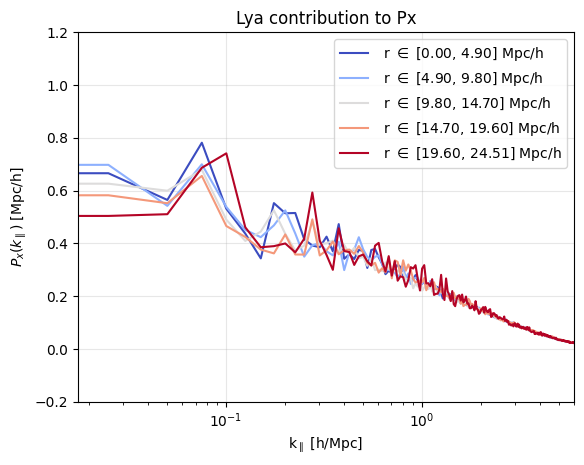

In [71]:
colors = plt.cm.coolwarm(np.linspace(0,1,len(r_bins)-1))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(px_lya)):
    plt.plot(k_los, px_lya[i], label=f' r $\\in$ [%.2f, %.2f] Mpc/h' %(r_bins[i], r_bins[i+1]))
plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.ylim(-0.2, 1.2)
plt.xlabel(r'k$_\parallel$ [h/Mpc]')
plt.ylabel(r'$P_x(k_\parallel)$ [Mpc/h]')
plt.title('Lya contribution to Px');

## HCD

In [37]:
px_hcd = []
for i, r_value in enumerate(r_bins[:-1]):
    r_mask = (dr_flatten_mask > r_value) & (dr_flatten_mask < r_bins[i+1])
    fft_hcd_2mask = fft_hcd_mask[r_mask]
    
    pxs_hcd = fft_hcd_2mask*fft_hcd_2mask.conjugate()*Lbox/(Np**2)
    px_hcd.append(np.mean(pxs_hcd, axis=0))
px_hcd = np.array(px_hcd)

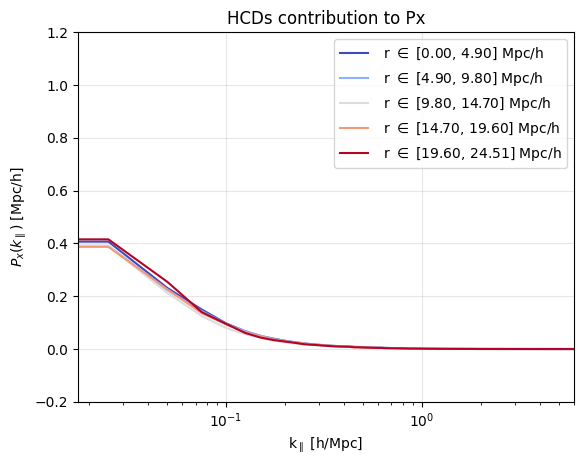

In [72]:
colors = plt.cm.coolwarm(np.linspace(0,1,len(r_bins)-1))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(px_hcd)):
    plt.plot(k_los, px_hcd[i], label=f' r $\\in$ [%.2f, %.2f] Mpc/h' %(r_bins[i], r_bins[i+1]))
plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.ylim(-0.2, 1.2)
plt.xlabel(r'k$_\parallel$ [h/Mpc]')
plt.ylabel(r'$P_x(k_\parallel)$ [Mpc/h]')
plt.title('HCDs contribution to Px');

## Lya x HCDs

In [53]:
px_lyahcd = []
for i, r_value in enumerate(r_bins[:-1]):
    r_mask = (dr_flatten_mask > r_value) & (dr_flatten_mask < r_bins[i+1])
    fft_lya_2mask = fft_lya_mask[r_mask]
    fft_hcd_2mask = fft_hcd_mask[r_mask]
    
    pxs_lyahcd = fft_lya_2mask*fft_hcd_2mask.conjugate()*Lbox/(Np**2)
    px_lyahcd.append(np.mean(pxs_lyahcd, axis=0))
px_lyahcd = np.array(px_lyahcd)

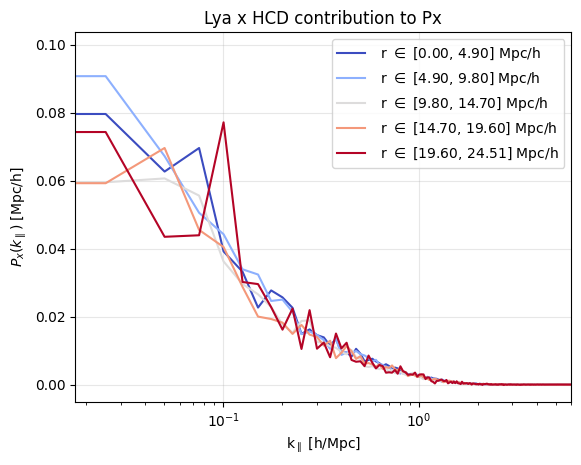

In [73]:
colors = plt.cm.coolwarm(np.linspace(0,1,len(r_bins)-1))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(px_lyahcd)):
    plt.plot(k_los, px_lyahcd[i], label=f' r $\\in$ [%.2f, %.2f] Mpc/h' %(r_bins[i], r_bins[i+1]))
plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.xlabel(r'k$_\parallel$ [h/Mpc]')
plt.ylabel(r'$P_x(k_\parallel)$ [Mpc/h]')
plt.title('Lya x HCD contribution to Px');

## 3Lya

In [41]:
px_3lya = []
for i, r_value in enumerate(r_bins[:-1]):
    r_mask = (dr_flatten_mask > r_value) & (dr_flatten_mask < r_bins[i+1])
    fft_lya_2mask = fft_lya_mask[r_mask]
    fft_lyahcd_2mask = fft_lyahcd_mask[r_mask]
    
    pxs_3lya = fft_lyahcd_2mask*fft_lya_2mask.conjugate()*Lbox/(Np**2)
    px_3lya.append(np.mean(pxs_3lya, axis=0))
px_3lya = np.array(px_3lya)

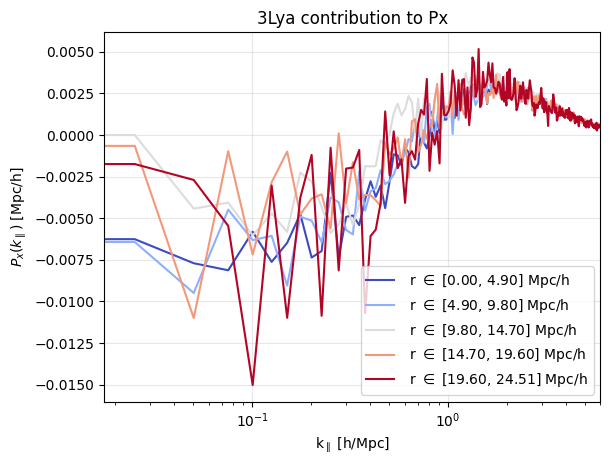

In [74]:
colors = plt.cm.coolwarm(np.linspace(0,1,len(r_bins)-1))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(px_3lya)):
    plt.plot(k_los, px_3lya[i], label=f' r $\\in$ [%.2f, %.2f] Mpc/h' %(r_bins[i], r_bins[i+1]))
plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.xlabel(r'k$_\parallel$ [h/Mpc]')
plt.ylabel(r'$P_x(k_\parallel)$ [Mpc/h]')
plt.title('3Lya contribution to Px');

## 3HCD

In [45]:
px_3hcd = []
for i, r_value in enumerate(r_bins[:-1]):
    r_mask = (dr_flatten_mask > r_value) & (dr_flatten_mask < r_bins[i+1])
    fft_hcd_2mask = fft_hcd_mask[r_mask]
    fft_lyahcd_2mask = fft_lyahcd_mask[r_mask]
    
    pxs_3hcd = fft_lyahcd_2mask*fft_hcd_2mask.conjugate()*Lbox/(Np**2)
    px_3hcd.append(np.mean(pxs_3hcd, axis=0))
px_3hcd = np.array(px_3hcd)

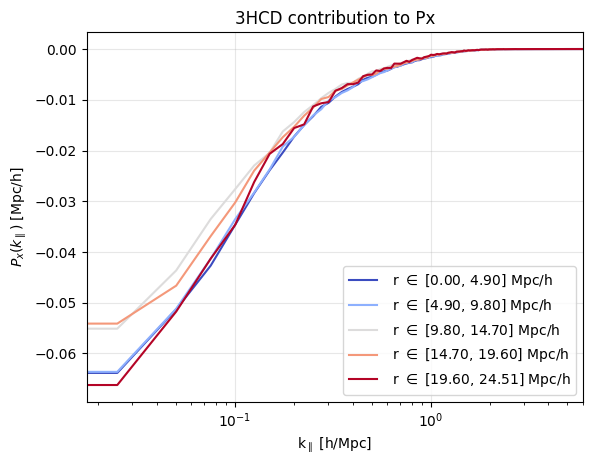

In [75]:
colors = plt.cm.coolwarm(np.linspace(0,1,len(r_bins)-1))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(px_3hcd)):
    plt.plot(k_los, px_3hcd[i], label=f' r $\\in$ [%.2f, %.2f] Mpc/h' %(r_bins[i], r_bins[i+1]))
plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.xlabel(r'k$_\parallel$ [h/Mpc]')
plt.ylabel(r'$P_x(k_\parallel)$ [Mpc/h]')
plt.title('3HCD contribution to Px');

## 4

In [48]:
px_4 = []
for i, r_value in enumerate(r_bins[:-1]):
    r_mask = (dr_flatten_mask > r_value) & (dr_flatten_mask < r_bins[i+1])
    fft_lyahcd_2mask = fft_lyahcd_mask[r_mask]
    
    pxs_4 = fft_lyahcd_2mask*fft_lyahcd_2mask.conjugate()*Lbox/(Np**2)
    px_4.append(np.mean(pxs_4, axis=0))
px_4 = np.array(px_4)

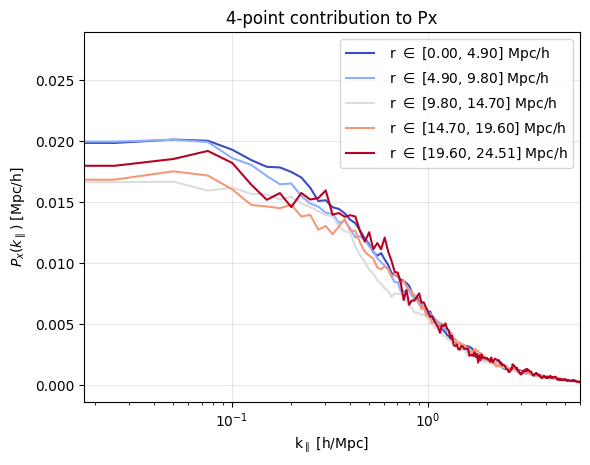

In [76]:
colors = plt.cm.coolwarm(np.linspace(0,1,len(r_bins)-1))     
plt.gca().set_prop_cycle('color', colors)

for i in np.arange(len(px_4)):
    plt.plot(k_los, px_4[i], label=f' r $\\in$ [%.2f, %.2f] Mpc/h' %(r_bins[i], r_bins[i+1]))
plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.xlabel(r'k$_\parallel$ [h/Mpc]')
plt.ylabel(r'$P_x(k_\parallel)$ [Mpc/h]')
plt.title('4-point contribution to Px');

# Plots

In [78]:
px_34 = 2*px_3lya + 2*px_3hcd + px_4
px_model = (px_lya + px_hcd + (2*px_lyahcd) + px_34)/((1+C)**2)

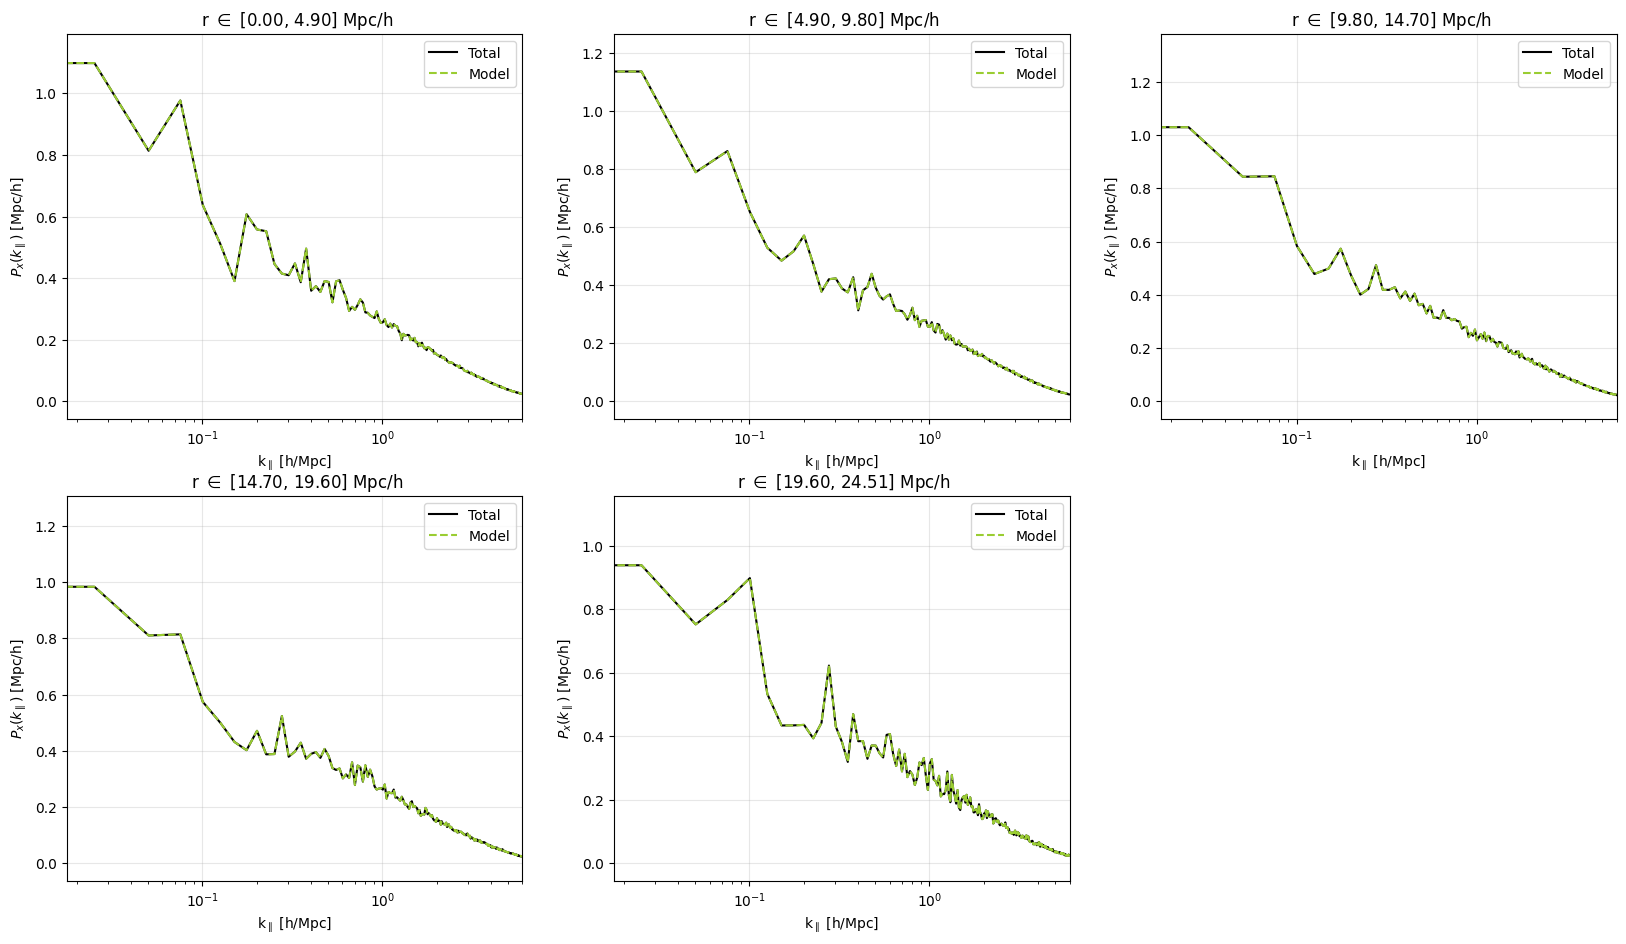

In [91]:
plt.figure(figsize=(20, 11))

for i in np.arange(len(r_bins)-1):
    plt.subplot(2, 3, i+1)
    plt.plot(k_los, px_tot[i], color='k', label='Total')
    plt.plot(k_los, px_model[i], linestyle='--', color='yellowgreen', label='Model')
    plt.xscale('log')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xlim(right=6)
    plt.xlabel(r'k$_\parallel$ [h/Mpc]')
    plt.ylabel(r'$P_x(k_\parallel)$ [Mpc/h]')
    plt.title(f' r $\\in$ [%.2f, %.2f] Mpc/h' %(r_bins[i], r_bins[i+1]))

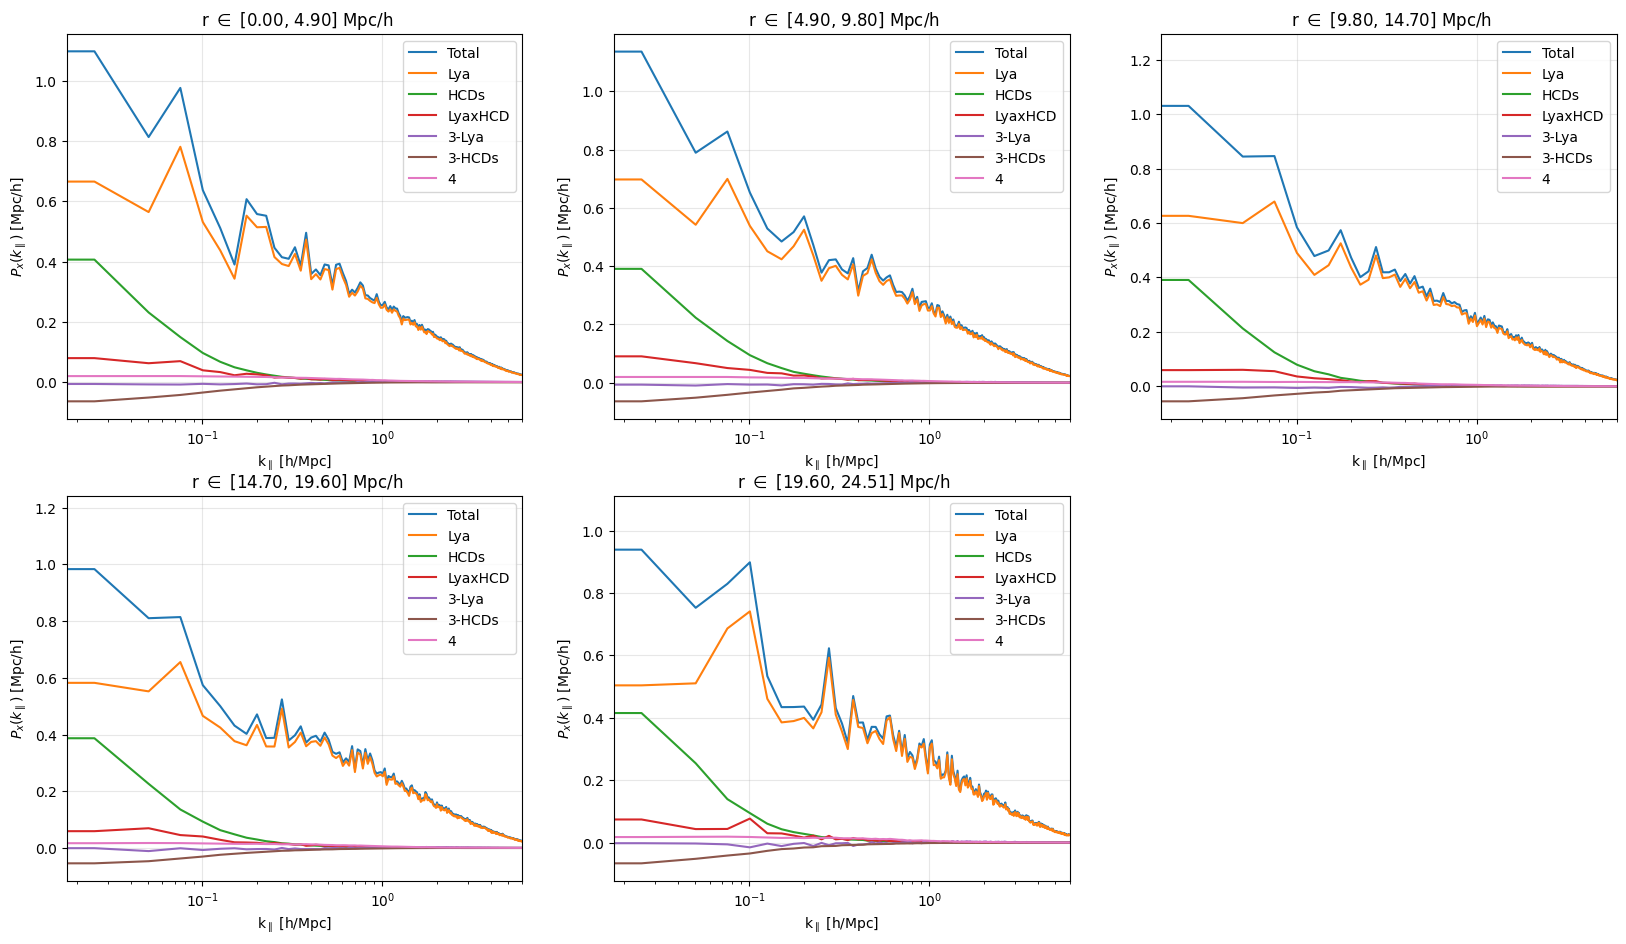

In [98]:
plt.figure(figsize=(20, 11))

for i in np.arange(len(r_bins)-1):
    plt.subplot(2, 3, i+1)
    plt.plot(k_los, px_tot[i], label='Total')
    plt.plot(k_los, px_lya[i], label='Lya')
    plt.plot(k_los, px_hcd[i], label='HCDs')
    plt.plot(k_los, px_lyahcd[i], label='LyaxHCD')
    plt.plot(k_los, px_3lya[i], label='3-Lya')
    plt.plot(k_los, px_3hcd[i], label='3-HCDs')
    plt.plot(k_los, px_4[i], label='4')
    plt.xscale('log')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xlim(right=6)
    plt.xlabel(r'k$_\parallel$ [h/Mpc]')
    plt.ylabel(r'$P_x(k_\parallel)$ [Mpc/h]')
    plt.title(f' r $\\in$ [%.2f, %.2f] Mpc/h' %(r_bins[i], r_bins[i+1]))

In [94]:
px_approx1 = px_lya+px_hcd+(2*px_lyahcd)/((1+C)**2)
px_approx2 = px_lya+px_hcd+(2*px_lyahcd)

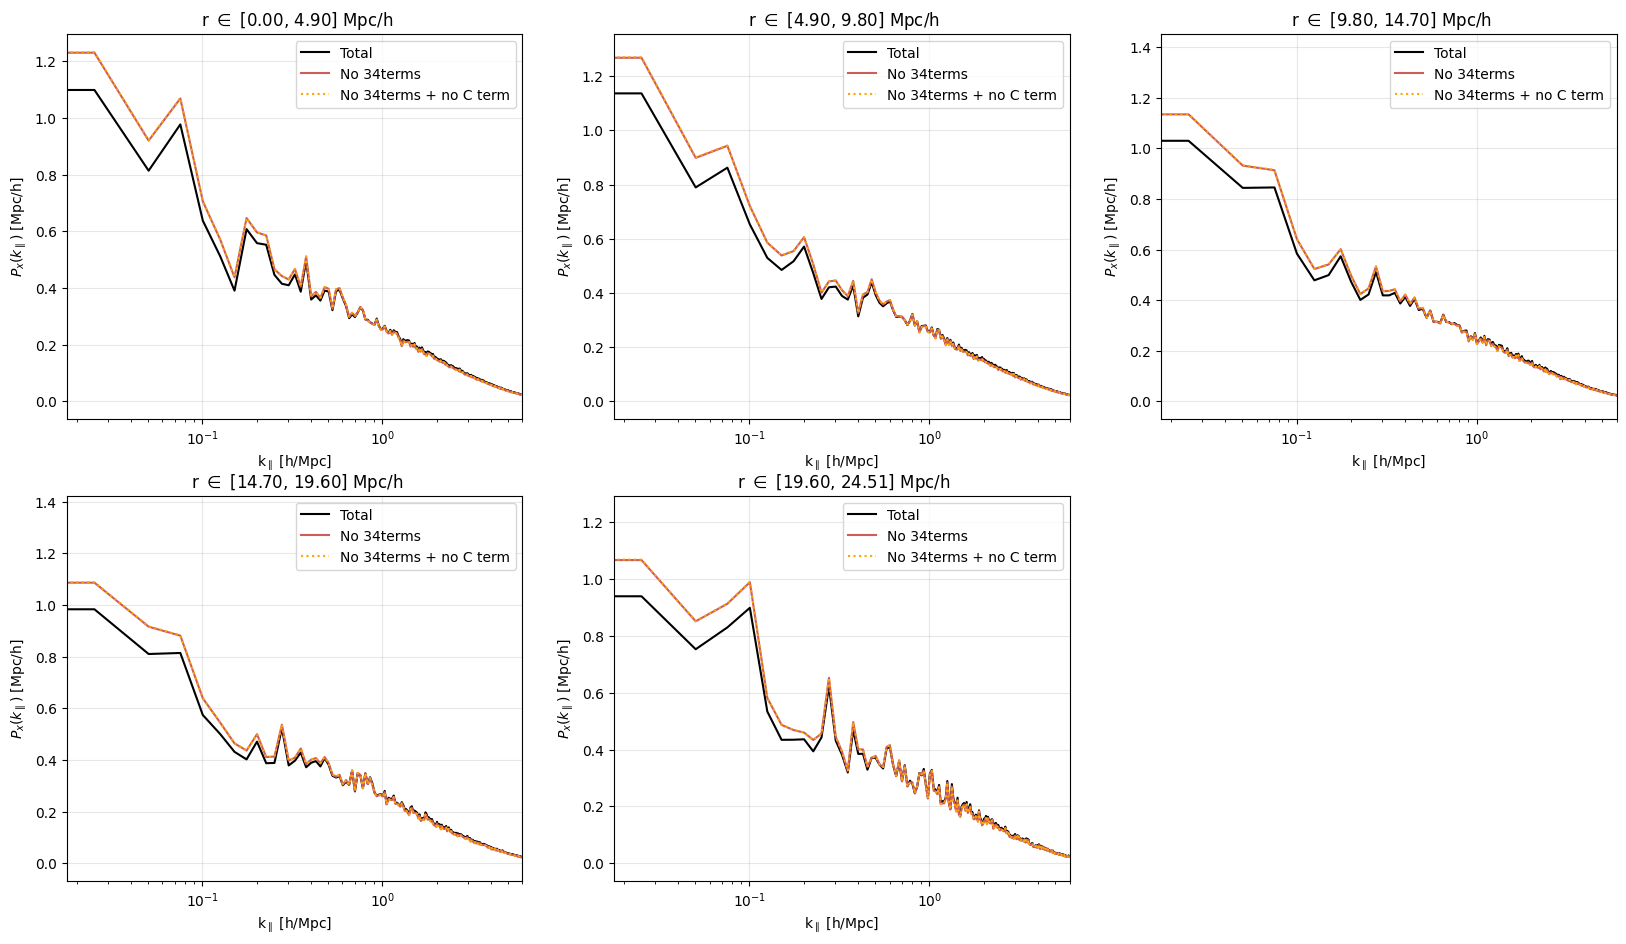

In [97]:
plt.figure(figsize=(20, 11))

for i in np.arange(len(r_bins)-1):
    plt.subplot(2, 3, i+1)
    plt.plot(k_los, px_tot[i], color='k', label='Total')
    plt.plot(k_los, px_approx1[i], color='indianred', label='No 34terms')
    plt.plot(k_los, px_approx2[i], color='orange', linestyle=':', label='No 34terms + no C term')
    plt.xscale('log')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xlim(right=6)
    plt.xlabel(r'k$_\parallel$ [h/Mpc]')
    plt.ylabel(r'$P_x(k_\parallel)$ [Mpc/h]')
    plt.title(f' r $\\in$ [%.2f, %.2f] Mpc/h' %(r_bins[i], r_bins[i+1]))

In [117]:
lost_info = np.mean((px_approx1-px_tot)*100, axis=0)

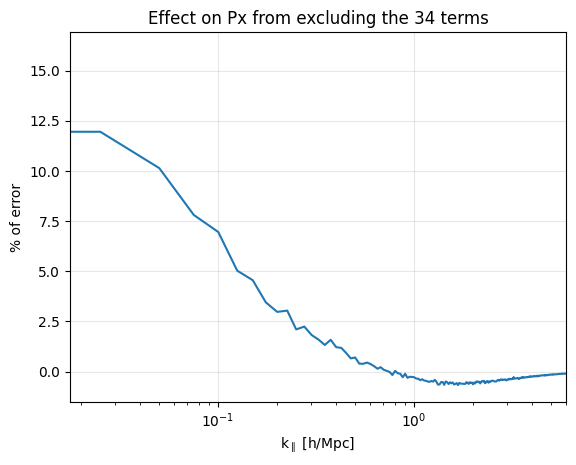

In [122]:
plt.plot(k_los, lost_info)
plt.xscale('log')
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.xlabel(r'k$_\parallel$ [h/Mpc]')
plt.ylabel('% of error')
plt.title('Effect on Px from excluding the 34 terms');